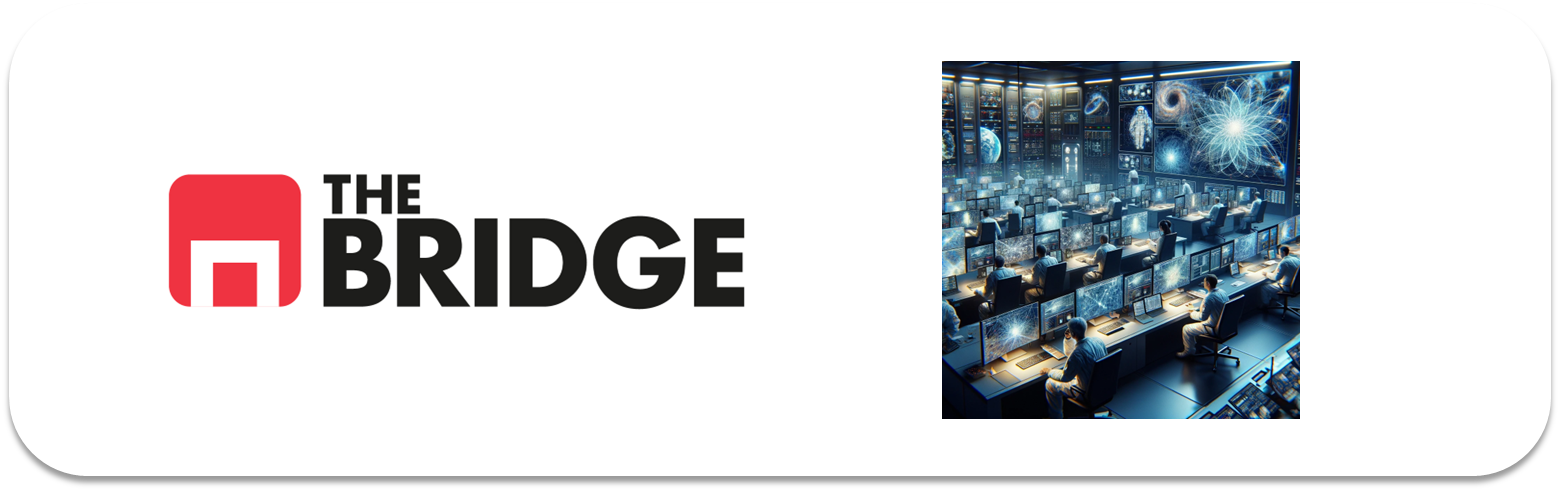

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import cv2
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from time import time

import gc # garbage collection


In [2]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
print(tf.test.gpu_device_name())

Num GPUs Available:  0



In [3]:
import kagglehub

# Dowload latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset file:", path)

100%|██████████| 346M/346M [00:13<00:00, 26.5MB/s] 

Extracting files...


Path to dataset file: C:\Users\helad\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



### 1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

In [4]:
ROOT_PATH = path

In [5]:
path

'C:\\Users\\helad\\.cache\\kagglehub\\datasets\\puneet6060\\intel-image-classification\\versions\\2'

In [8]:
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [9]:
os.listdir(path + "/seg_train")

['seg_train']

In [11]:
os.listdir(path + "/seg_train/seg_train")

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [13]:
TRAIN_PATH = ROOT_PATH + "/seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "/seg_test/seg_test/"

In [14]:
os.listdir(TRAIN_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [15]:
os.listdir(TEST_PATH)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

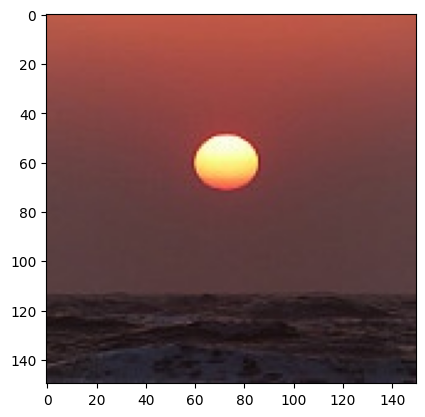

In [18]:
plt.imshow(imread(TRAIN_PATH + "/sea/" + "11321.jpg"))
plt.show()

In [19]:
imread(TRAIN_PATH + "/sea/" + "11321.jpg").shape

(150, 150, 3)

*Vamos a introducir un parametro de control de la resolución, según las dimensiones de entrada de nuestra red, pero que*  
*podamos tocar sin cambiar nada del resto del código para poder probar otrar resoluciones*

In [20]:
IMG_WIDTH = IMG_HEIGHT = 75

In [21]:
def read_data(directorio, reshape_dim = (IMG_WIDTH,IMG_HEIGHT)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        print(folder)
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 75x75

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)

def show_images_batch(paisajes, names = [], n_cols = 5, size_scale = 2):
    n_rows = ((len(paisajes) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * size_scale, n_rows * 1.1*size_scale))
    for index, paisaje in enumerate(paisajes):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(paisaje, cmap = "Greys")
        plt.axis("off")
        if len(names):
            plt.title(names[index])

In [22]:
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

buildings
forest
glacier
mountain
sea
street
buildings
forest
glacier
mountain
sea
street


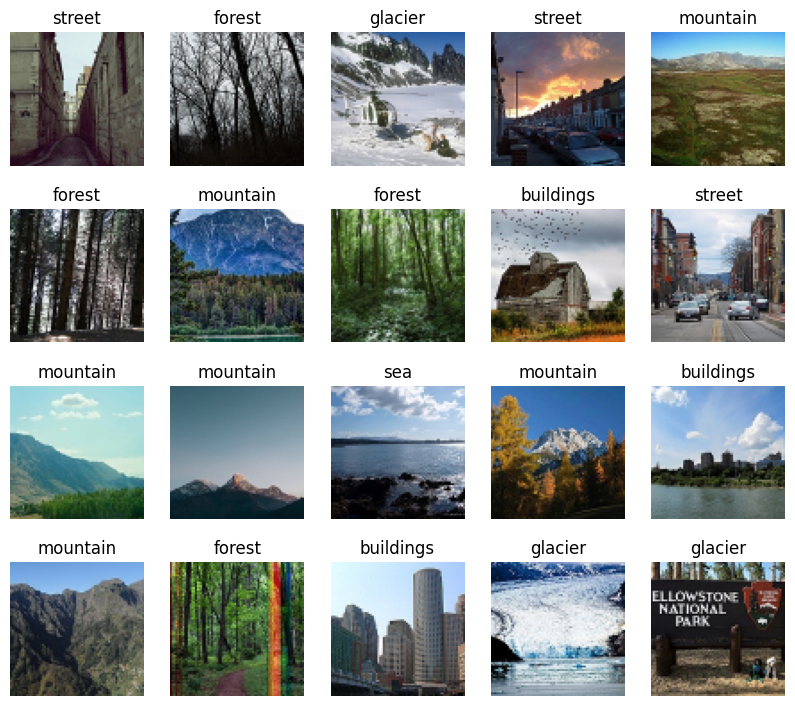

In [23]:
indices = np.random.randint(0, len(X_train), 20)
show_images_batch(X_train[indices], names = y_train[indices], n_cols = 5)

In [24]:
X_train.shape

(14034, 75, 75, 3)

In [25]:
X_train.size

236823750

In [26]:
X_test.shape

(3000, 75, 75, 3)

*Escalamos entre -1 y 1 porque Inception lo requiere así (según documentación)*

In [27]:
X_train = (X_train/127.5) -1.0
X_test = (X_test/127.5) - 1.0

### 2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

In [30]:
from keras.applications import InceptionV3

### 3. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

*Para el transfer learning vamos a usar una cabeza con una única capa densa con tantas unidades como el aplanamiento de las imagenes, es decir dependiendo de la resolución con la que hayamos cargado las imágenes al principio así tendremos una cantidad u otra de unidades*

In [29]:
X_train.size

236823750

In [31]:
test_model = InceptionV3(include_top= False, weights= 'imagenet', input_shape= (75, 75, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [34]:
test_model

<Functional name=inception_v3, built=True>

In [32]:
test_model.input

<KerasTensor shape=(None, 75, 75, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>

In [33]:
test_model.output

<KerasTensor shape=(None, 1, 1, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_310>

In [35]:
del test_model
gc.collect()

38003

In [37]:
IMG_WIDTH = IMG_HEIGHT = 75

# Cargamos el modelo pre-entrenado

base_model = InceptionV3(include_top= False, weights='imagenet', input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Congelamos sus capas

for layer in base_model.layers:
    layer.trainable = False

# Capa de aplanado de la salida del modelo base

def prepare_model(base_model = base_model): # Lo creamos así para poder reinicializarlo en cada reentrenami

    x = keras.layers.Flatten()(base_model.output)

    # Tantas unidades como el flatten de la salida de Inception -> 2048 features
    x = keras.layers.Dense(2048, activation='relu')(x)
    x = keras.layers.Dropout(rate = 0.25)(x)

    # Capa final de salida con 6 neuronas (una por clase) y activación softmax
    x = keras.layers.Dense(6, activation='softmax')(x)

    model = keras.Model(base_model.input, x)

    model.compile(
        optimizer = "adam",
        loss = 'sparse_categorical_crossentropy', # sparse -> y es un array de escalares pero hay varias ca
        metrics = ['acc']
        )

    return model

# Observamos la arquitectura del modelo
model = prepare_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 37, 37,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 37,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 35, 35,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 35, 35,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 17, 17,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 17, 17,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 15, 15,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 26,011,430 (99.23 MB)

 Trainable params: 4,208,646 (16.05 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

*Ahora vamos a configurar el resto de hiperparámetros, el batch_size, el número de épocas y el EarlyStopping*

In [38]:
instancias_train = len(X_train)

for i in range(1,5):
    print(f"Batch_size: {32*i}, num_steps_per_epoch: {round(instancias_train*0.8/(32*i))}")

Batch_size: 32, num_steps_per_epoch: 351
Batch_size: 64, num_steps_per_epoch: 175
Batch_size: 96, num_steps_per_epoch: 117
Batch_size: 128, num_steps_per_epoch: 88


In [39]:
y_train

array(['buildings', 'buildings', 'buildings', ..., 'street', 'street',
       'street'], shape=(14034,), dtype='<U9')

In [40]:
targets = pd.Series(y_train)

In [42]:
mapa = {tipo: indice for indice, tipo in enumerate(targets.unique())}
mapa

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [43]:
y_train_num = np.array([mapa[y] for y in y_train])
y_test_num = np.array([mapa[y] for y in y_test])

In [44]:
y_train_num

array([0, 0, 0, ..., 5, 5, 5], shape=(14034,))

In [45]:
from sklearn.utils import shuffle
X_train_s, y_train_s = shuffle(X_train, y_train_num)

In [ ]:
# from time import time

# for batch_size in [32,64,96,128]:
# t_zero = time()
# model = prepare_model()
# model.fit(X_train,
#             y_train_num,
#             batch_size = batch_size,
#             validation_split=0.2,
#             epochs=1)
# tiempo = round(time() - t_zero, 3)

# del model
# gc.collect()

# print(f"batch_size: {batch_size}, num_steps: {len(X_train)/batch_size}, tiempo 1 epoca: {tiempo}, tiempo épocas: {tiempo * 20}")

*vamos a por los 128 de batch size*

In [46]:
batch_size = 128

In [47]:
earlyS = keras.callbacks.EarlyStopping(patience= 10, restore_best_weights= True)

In [48]:
t_zero = time()

In [49]:
t_zero = time()
model = prepare_model()
history = model.fit(X_train_s,
                    y_train_s,
                    batch_size = batch_size,
                    validation_split=0.2,
                    epochs=40,
                    callbacks = [earlyS])
tiempo = round(time() - t_zero, 3)

Epoch 1/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - acc: 0.7074 - loss: 0.8815 - val_acc: 0.7702 - val_loss: 0.6212
Epoch 2/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - acc: 0.8247 - loss: 0.4811 - val_acc: 0.7969 - val_loss: 0.5621
Epoch 3/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - acc: 0.8729 - loss: 0.3543 - val_acc: 0.7948 - val_loss: 0.5612
Epoch 4/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - acc: 0.9115 - loss: 0.2582 - val_acc: 0.7870 - val_loss: 0.6060
Epoch 5/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - acc: 0.9450 - loss: 0.1708 - val_acc: 0.7976 - val_loss: 0.5931
Epoch 6/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - acc: 0.9704 - loss: 0.1108 - val_acc: 0.7955 - val_loss: 0.6387
Epoch 7/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - acc: 0.9874 - loss: 0.0653 - val_acc: 0.8019 - val_loss: 0.6906
Epoch 8/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - acc: 0.9944 - loss: 0.0426 - val_acc: 0.8001 - val_loss: 0.6969
Epoch 9/40
88/88 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - acc: 0.9972 -

*Evaluamos*

In [50]:
model.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - acc: 0.7973 - loss: 0.5661


[0.5660712122917175, 0.7973333597183228]

In [51]:
y_pred = [np.argmax(prediction) for prediction in model.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 318ms/step


In [52]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
inverse_map = {valor:clave for clave,valor in mapa.items()}

y_test_labels = [inverse_map[y] for y in y_test_num]
y_pred_labels = [inverse_map[y] for y in y_pred]
print(classification_report(y_test_labels, y_pred_labels))

              precision    recall  f1-score   support

   buildings       0.76      0.87      0.81       437
      forest       0.93      0.95      0.94       474
     glacier       0.75      0.70      0.72       553
    mountain       0.71      0.74      0.72       525
         sea       0.80      0.77      0.78       510
      street       0.86      0.79      0.82       501

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000



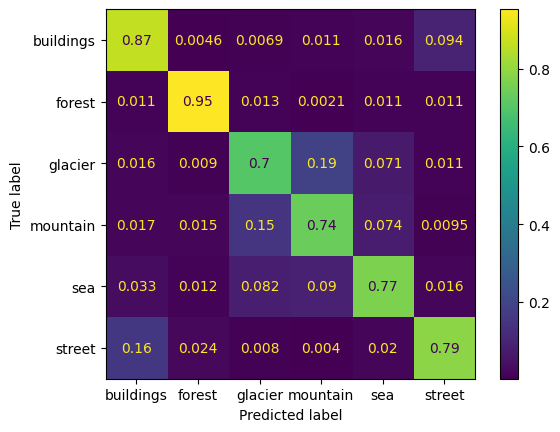

In [53]:
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, normalize="true")
plt.show()

In [54]:
del model
del history
gc.collect()

9139

### 4. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

### 5. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

### EXTRA: Repetir el transfer learning empleando aumentado de imágenes.